In [1]:
import os
from pathlib import Path

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))  # go to ~/crossdem/ by jumping up twice
OUT_DIR = os.path.join(BASE_DIR, "datasets")

os.makedirs(OUT_DIR, exist_ok=True)

#with open(os.path.join(OUT_DIR, "output.txt"), "w") as f:
#    f.write("hello world")
#
#print(f"Written to {OUT_DIR}/output.txt")

# Textual Analysis


In [2]:
import pandas
import glob

all_melonis = glob.glob(f"{BASE_DIR}/datasets/meloni/csv_out/*.csv")
meloni_df =  pandas.concat([pandas.read_csv(f, nrows=1) for f in all_melonis], ignore_index=True)

degasperi_df = pandas.read_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_speeches.csv")

meloni_df.head()

,politician,historical_date,location,tags,description,title,url,audio_file,text
0,meloni,2026-05-21,NISCEMI,[],"Il Presidente del Consiglio, Giorgia Meloni, s...",Punto stampa del Presidente Giorgia Meloni a N...,https://youtu.be/iOFR7Ae9cHU?si=0jxlIq30L1GWEz6v,crossdem/datasets/meloni/audio_out/WEz6v_audio...,Diciamo cosa è venuto fuori da questa riunione...
1,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Punto stampa del Presidente Giorgia Meloni pri...,https://youtu.be/i4Dyv8CQ7VA?si=dmvMAn8kQ7L65bjC,crossdem/datasets/meloni/audio_out/65bjC_audio...,"Mi pare un incontro molto ampio, molto costrut..."
2,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Il Presidente Giorgia Meloni interviene a “L’A...,https://youtu.be/F4-PR5iJv0E?si=xOoatF-_4Kz6rOAc,crossdem/datasets/meloni/audio_out/6rOAc_audio...,"Buon pomeriggio a tutti, grazie per l'invito, ..."
3,meloni,2026-05-07,NaN,[],#agricoltori #cia #giorgiameloni #governomeloni,L'intervento di Giorgia Meloni in occasione de...,https://youtu.be/A_pHRztwshY?si=g12j2iNOGap5gm3A,crossdem/datasets/meloni/audio_out/5gm3A_audio...,L'Italia è a tutti gli effetti una super poten...
4,meloni,2026-05-06,REGIONE AUTONOMA FRIULI - VENEZIA GIULIA - CON...,[],Il mio intervento alla seduta straordinaria de...,L'intervento di Giorgia Meloni per il 50° anni...,https://youtu.be/RL-q9N7EtQE?si=gnA73YDdUye1GqzU,crossdem/datasets/meloni/audio_out/1GqzU_audio...,"Presidente della Repubblica, Distinte Autorità..."


In [4]:
degasperi_df.head()

,politician,historical_date,location,keywords,text
0,degasperi,1906-02-13,Trento,"['conseguenze del suffragio universale', 'part...",[...] La modalità del suffragio universale Qua...
1,degasperi,1902-01-2,Trento,"['questione universitaria', 'università italia...",[...] Incaricato dalla Presidenza dell’Associa...
2,degasperi,1906-05-15,Trento,"['suffragio universale', 'popoli', 'deputati',...",Introduzione Necessità di far politica Chi par...
3,degasperi,1906-09-10,Trento,"['applausi prolungati', 'studente carbonari', ...",[...] Parla il dott. Degasperi Entrando staman...
4,degasperi,1906-12-10,Trento,"['clericali', 'liberale', 'don rodrigo', 'clas...",La classificazione dei partiti riesce oltremod...



## Number of tokens per PM
> Measures the amount of collected data


In [5]:
import spacy

# Load Italian model if your speeches are in Italian, otherwise use en_core_web_sm
# pip install spacy && python3 -m spacy download it_core_news_sm
nlp = spacy.load("it_core_news_sm")


In [6]:

# Disable unneeded pipeline components for speed — we only need tokenization
nlp.select_pipes(enable=[])  # disables everything except tokenizer

def count_tokens(text):
    if pandas.isna(text) or not isinstance(text, str):
        return 0
    return len(nlp(text))

# Normalize column names so both DFs have 'text'
meloni_df["token_count"] = meloni_df["text"].apply(count_tokens)
degasperi_df["token_count"] = degasperi_df["text"].apply(count_tokens)

# Combine
combined_df = pandas.concat(
    [meloni_df[["politician", "token_count"]], degasperi_df[["politician", "token_count"]]],
    ignore_index=True
)

# Aggregate
token_summary = (
    combined_df
    .groupby("politician")["token_count"]
    .agg(total_tokens="sum", speech_count="count", avg_tokens_per_speech="mean")
    .reset_index()
)

print(token_summary)

  politician  total_tokens  speech_count  avg_tokens_per_speech
0  degasperi        609142           473            1287.826638
1     meloni        120116            72            1668.277778



## MTLD Measure of Textual Lexical Diversity
> Measures lexical diversity

By sequentially evaluating the Type-Token Ratio (TTR) across segments, MTLD avoids the common problem of shorter texts artificially inflating lexical diversity 


In [7]:
from lexicalrichness import LexicalRichness

def compute_mtld(text):
    lex = LexicalRichness(text)
    # Need at least a few tokens for a meaningful MTLD
    if lex.words < 10:
        return None
    return lex.mtld(threshold=0.72)

meloni_df["mtld"] = meloni_df["text"].apply(compute_mtld)
degasperi_df["mtld"] = degasperi_df["text"].apply(compute_mtld)

combined_df = pandas.concat(
    [meloni_df[["politician", "mtld"]], degasperi_df[["politician", "mtld"]]],
    ignore_index=True
)

mtld_summary = (
    combined_df
    .groupby("politician")["mtld"]
    .agg(
        avg_mtld="mean",
        median_mtld="median",
        speech_count="count"
    )
    .reset_index()
)

print(mtld_summary)
meloni_df.head()
#degasperi_df.head()

  politician    avg_mtld  median_mtld  speech_count
0  degasperi  141.829723   137.642465           473
1     meloni  106.745090   104.917560            72


,politician,historical_date,location,tags,description,title,url,audio_file,text,token_count,mtld
0,meloni,2026-05-21,NISCEMI,[],"Il Presidente del Consiglio, Giorgia Meloni, s...",Punto stampa del Presidente Giorgia Meloni a N...,https://youtu.be/iOFR7Ae9cHU?si=0jxlIq30L1GWEz6v,crossdem/datasets/meloni/audio_out/WEz6v_audio...,Diciamo cosa è venuto fuori da questa riunione...,323,118.884516
1,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Punto stampa del Presidente Giorgia Meloni pri...,https://youtu.be/i4Dyv8CQ7VA?si=dmvMAn8kQ7L65bjC,crossdem/datasets/meloni/audio_out/65bjC_audio...,"Mi pare un incontro molto ampio, molto costrut...",161,147.974359
2,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Il Presidente Giorgia Meloni interviene a “L’A...,https://youtu.be/F4-PR5iJv0E?si=xOoatF-_4Kz6rOAc,crossdem/datasets/meloni/audio_out/6rOAc_audio...,"Buon pomeriggio a tutti, grazie per l'invito, ...",2882,111.974395
3,meloni,2026-05-07,NaN,[],#agricoltori #cia #giorgiameloni #governomeloni,L'intervento di Giorgia Meloni in occasione de...,https://youtu.be/A_pHRztwshY?si=g12j2iNOGap5gm3A,crossdem/datasets/meloni/audio_out/5gm3A_audio...,L'Italia è a tutti gli effetti una super poten...,555,125.975642
4,meloni,2026-05-06,REGIONE AUTONOMA FRIULI - VENEZIA GIULIA - CON...,[],Il mio intervento alla seduta straordinaria de...,L'intervento di Giorgia Meloni per il 50° anni...,https://youtu.be/RL-q9N7EtQE?si=gnA73YDdUye1GqzU,crossdem/datasets/meloni/audio_out/1GqzU_audio...,"Presidente della Repubblica, Distinte Autorità...",1890,99.529327


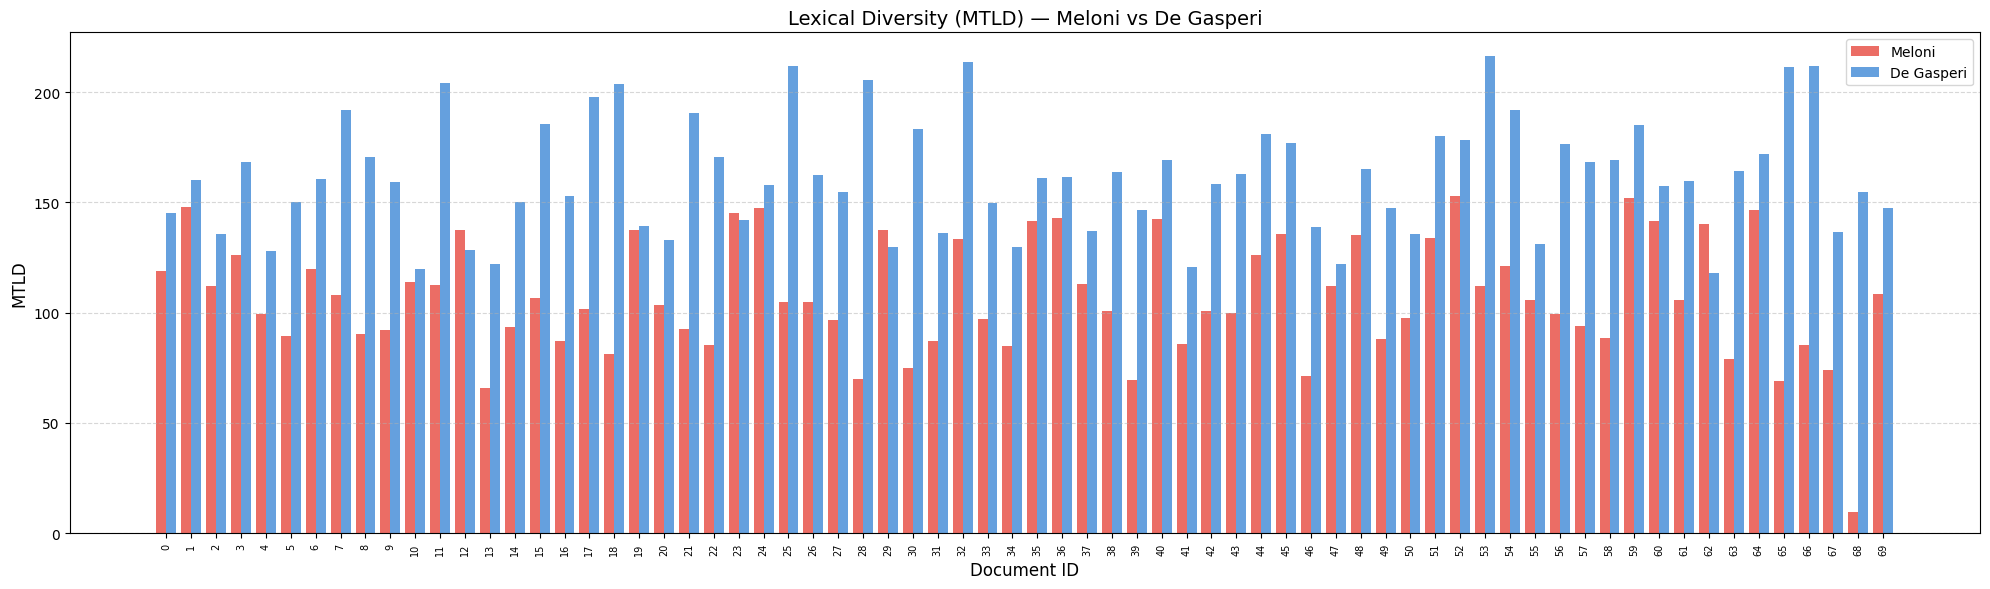

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Take first 70 docs from each
meloni_plot = meloni_df["mtld"].dropna().head(70).reset_index(drop=True)
degasperi_plot = degasperi_df["mtld"].dropna().head(70).reset_index(drop=True)

x = np.arange(70)
width = 0.4

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - width/2, meloni_plot, width, label="Meloni", color="#E8534A", alpha=0.85)
ax.bar(x + width/2, degasperi_plot, width, label="De Gasperi", color="#4A90D9", alpha=0.85)

ax.set_xlabel("Document ID", fontsize=12)
ax.set_ylabel("MTLD", fontsize=12)
ax.set_title("Lexical Diversity (MTLD) — Meloni vs De Gasperi", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90, fontsize=7)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("mtld_comparison.png", dpi=150)
plt.show()


## Vocabulary Differences
> What are words that are used by De Gasperi and not by Meloni? And vice-versa

> What are the words most commonly used by De Gasperi and what by Meloni? 


In [ ]:
# --- Tokenize and collect words (lowercase, alpha only) ---
def tokenize(text):
    return [token.text.lower() for token in nlp(text) 
            if token.is_alpha 
            and not token.is_stop 
            and len(token)>3
            ]

degasperi_words = []
meloni_words = []

for text in degasperi_df["text"]:
    degasperi_words.extend(tokenize(text))

for text in meloni_df["text"]:
    meloni_words.extend(tokenize(text))


### Words used only by De Gasperi and words used only by Meloni

In [10]:
# --- Top 1000 most frequent words per politician ---
from collections import Counter
degasperi_freq = Counter(degasperi_words)
meloni_freq    = Counter(meloni_words)

top1000_degasperi = {word for word, _ in degasperi_freq.most_common(1000)}
top1000_meloni    = {word for word, _ in meloni_freq.most_common(1000)}

# --- How different are the two top-1000 sets? ---
overlap     = top1000_degasperi & top1000_meloni
union       = top1000_degasperi | top1000_meloni
jaccard     = len(overlap) / len(union)          # 0 = totally different, 1 = identical

print(f"\nTop-1000 overlap:     {len(overlap)} words in common")
print(f"Jaccard similarity:   {jaccard:.2%}")


Top-1000 overlap:     487 words in common
Jaccard similarity:   32.19%


In [11]:
# --- Words in BOTH top-1000s, sorted by combined frequency ---
common_top1000 =  top1000_meloni & top1000_degasperi
ROWS_TO_PRINT = 20

print(f"=== Highest frequency common words ({len(common_top1000)} words) ===")
for word in sorted(common_top1000, key=lambda w: degasperi_freq[w] + meloni_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} degasperi: {degasperi_freq[word]:>6}   meloni: {meloni_freq[word]:>6}   freq sum: {meloni_freq[word]+degasperi_freq[word]:>6}")

# --- In Meloni's top-1000 but NOT De Gasperi's, sorted by Meloni frequency ---
meloni_not_degasperi = {w for w in top1000_meloni if degasperi_freq[w] == 0}

print(f"\n=== Highest frequency words in Meloni, not in De Gasperi ({len(meloni_not_degasperi)} words) ===")
for word in sorted(meloni_not_degasperi, key=lambda w: meloni_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} meloni: {meloni_freq[word]:>6}   degasperi: {degasperi_freq[word]:>6}")

# --- In De Gasperi's top-1000 but NOT Meloni's, sorted by De Gasperi frequency ---
degasperi_not_meloni = {w for w in top1000_degasperi if meloni_freq[w] == 0}

print(f"\n=== Highest frequency words in De Gasperi, not in Meloni  ({len(degasperi_not_meloni)} words) ===")
for word in sorted(degasperi_not_meloni, key=lambda w: degasperi_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} degasperi: {degasperi_freq[word]:>6}   meloni: {meloni_freq[word]:>6}")

=== Highest frequency common words (487 words) ===
  italia                    degasperi:   1544   meloni:    423   freq sum:   1967
  popolo                    degasperi:   1155   meloni:     46   freq sum:   1201
  libertà                   degasperi:    980   meloni:     91   freq sum:   1071
  guerra                    degasperi:    869   meloni:     58   freq sum:    927
  politica                  degasperi:    783   meloni:    129   freq sum:    912
  pace                      degasperi:    841   meloni:     69   freq sum:    910
  italiano                  degasperi:    758   meloni:     70   freq sum:    828
  presidente                degasperi:    509   meloni:    224   freq sum:    733
  democrazia                degasperi:    679   meloni:     29   freq sum:    708
  partito                   degasperi:    669   meloni:     13   freq sum:    682
  bisogna                   degasperi:    587   meloni:     74   freq sum:    661
  italiani                  degasperi:    531  

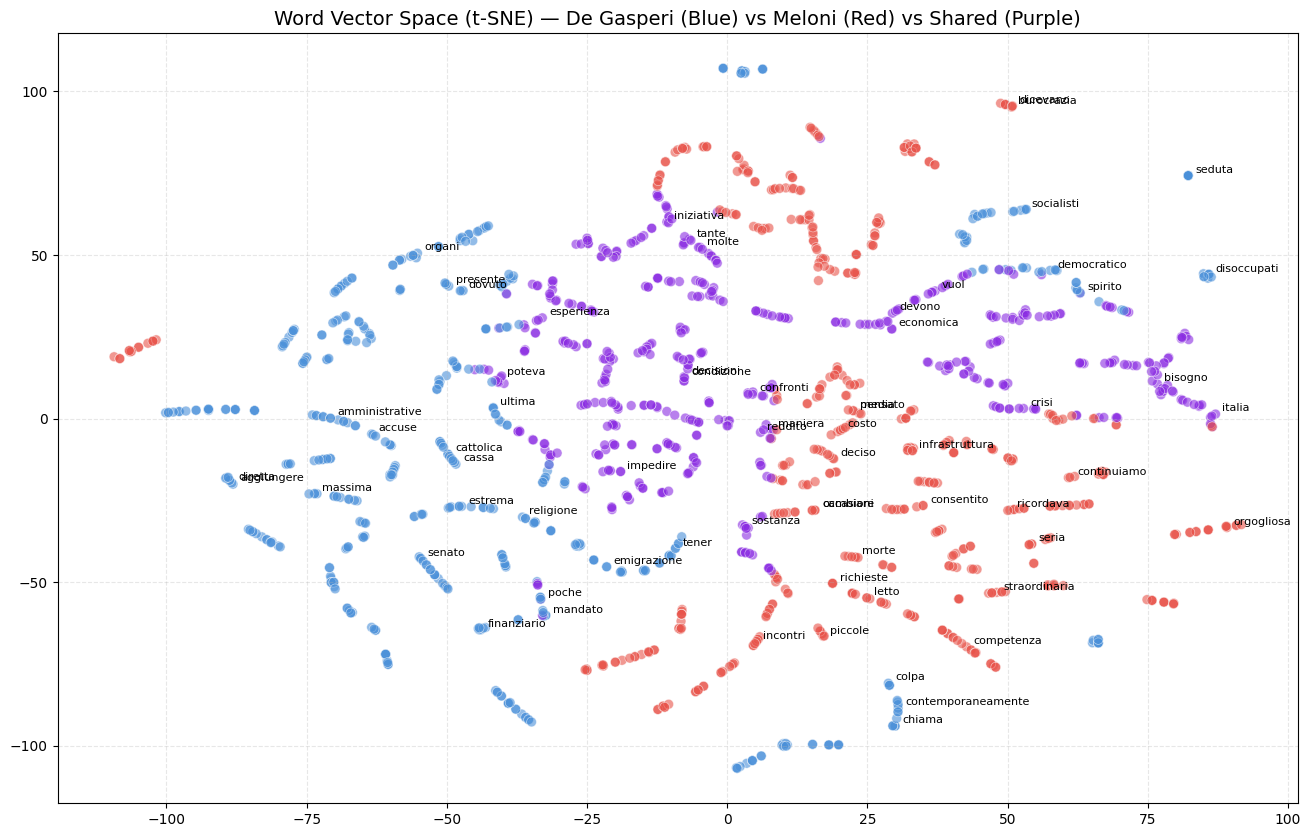

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# --- CONFIGURATION CONSTANTS ---
MAX_LABELS = 80  # Total maximum number of data points that get a label
# -------------------------------

# 1. Define your corpus properly
degasperi_full_text = " ".join(degasperi_words)
meloni_full_text = " ".join(meloni_words)
corpus = [degasperi_full_text, meloni_full_text]

# 2. Get the unique set of your top 1000 words from both speakers
combined_top_words = list(top1000_degasperi.union(top1000_meloni))

# 3. Vectorize ONLY your top words
vectorizer = TfidfVectorizer(vocabulary=combined_top_words)
X = vectorizer.fit_transform(corpus)
word_vectors = X.T.toarray()

# 4. Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='random')
word_coords = tsne.fit_transform(word_vectors)

# 5. Determine colors for ALL dots based on ownership
dot_colors = []
for word in combined_top_words:
    if word in top1000_degasperi and word in top1000_meloni:
        dot_colors.append('#8A2BE2') # Purple (Shared)
    elif word in top1000_degasperi:
        dot_colors.append('#4A90D9') # Blue (De Gasperi)
    else:
        dot_colors.append('#E8534A') # Red (Meloni)

# 6. Define which words get labeled using MAX_LABELS
# Split the quota evenly between De Gasperi and Meloni lists
half_max = MAX_LABELS // 2
words_to_label = list(top1000_degasperi)[:half_max] + list(top1000_meloni)[:half_max]

# 7. Plot the graphical view
plt.figure(figsize=(16, 10))

# Plot all dots with their respective ownership colors
plt.scatter(word_coords[:, 0], word_coords[:, 1], alpha=0.6, c=dot_colors, edgecolors='w', linewidth=0.5, s=50)

# Annotate the subset of words
for i, word in enumerate(combined_top_words):
    if word in words_to_label:
        # The label matches the dot color determined in step 5
        label_color = dot_colors[i]
        
        # Added a slight offset to the text so it doesn't sit directly on top of the dot
        plt.annotate(
            word, 
            (word_coords[i, 0], word_coords[i, 1]), 
            xytext=(5, 2), 
            textcoords='offset points', 
            fontsize=8, 
            color='black', 
            weight='normal'
        )

plt.title(f"Word Vector Space (t-SNE) — De Gasperi (Blue) vs Meloni (Red) vs Shared (Purple)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


## Sentiment Analysis

Oss: BERT cannot handle more than 512 tokens in one go
Oss: he raw probability scores and report distributions (e.g. median positive score per PM, per year) rather than hard positive/negative counts

### nlptown/bert-base-multilingual-uncased-sentiment

In [14]:
from transformers import pipeline



def sentiment(df):
    # 1. Initialize the new multilingual sentiment pipeline
    sentiment_classifier = pipeline(
        "text-classification",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        device=0  # GPU
    )

    # --- Assuming your DataFrame is loaded as 'df' ---
    # Example: df = pd.read_csv("political_transcripts.csv")
    df = df.dropna(subset=['text']).copy()
    texts = df['text'].tolist()

    # 2. Run the predictions with batching and truncation
    batch_size = 16 

    print("Running sentiment analysis...")
    sentiment_results = sentiment_classifier(
        texts, 
        batch_size=batch_size, 
        truncation=True, 
        max_length=512
    )

    df['sentiment_label'] = [res['label'] for res in sentiment_results]
    df['sentiment_score'] = [res['score'] for res in sentiment_results]

    # Calculate the aggregated score for each result in the list
    df['sentiment_aggregated'] = [
        (int(res['label'].split()[0]) * res['score']) / 5 
        for res in sentiment_results
    ]
    return df

meloni_df = sentiment(meloni_df)
degasperi_df = sentiment(degasperi_df)

meloni_df.to_csv(f"{BASE_DIR}/datasets/meloni/meloni_processed.csv")
degasperi_df.to_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_processed.csv")
degasperi_df.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...


,politician,historical_date,location,keywords,text,token_count,mtld,sentiment_label,sentiment_score,sentiment_aggregated
0,degasperi,1906-02-13,Trento,"['conseguenze del suffragio universale', 'part...",[...] La modalità del suffragio universale Qua...,1313,145.027312,2 stars,0.370492,0.148197
1,degasperi,1902-01-2,Trento,"['questione universitaria', 'università italia...",[...] Incaricato dalla Presidenza dell’Associa...,3449,159.972801,2 stars,0.289392,0.115757
2,degasperi,1906-05-15,Trento,"['suffragio universale', 'popoli', 'deputati',...",Introduzione Necessità di far politica Chi par...,2258,135.551367,2 stars,0.405345,0.162138
3,degasperi,1906-09-10,Trento,"['applausi prolungati', 'studente carbonari', ...",[...] Parla il dott. Degasperi Entrando staman...,491,168.422781,5 stars,0.227740,0.227740
4,degasperi,1906-12-10,Trento,"['clericali', 'liberale', 'don rodrigo', 'clas...",La classificazione dei partiti riesce oltremod...,1064,128.144265,2 stars,0.411749,0.164699


In [15]:
# Calculate medians
degasperi_median = degasperi_df['sentiment_aggregated'].median()
meloni_median = meloni_df['sentiment_aggregated'].median()

print(f"De Gasperi Median Sentiment: {degasperi_median:.3f}")
print(f"Meloni Median Sentiment: {meloni_median:.3f}")

De Gasperi Median Sentiment: 0.265
Meloni Median Sentiment: 0.379


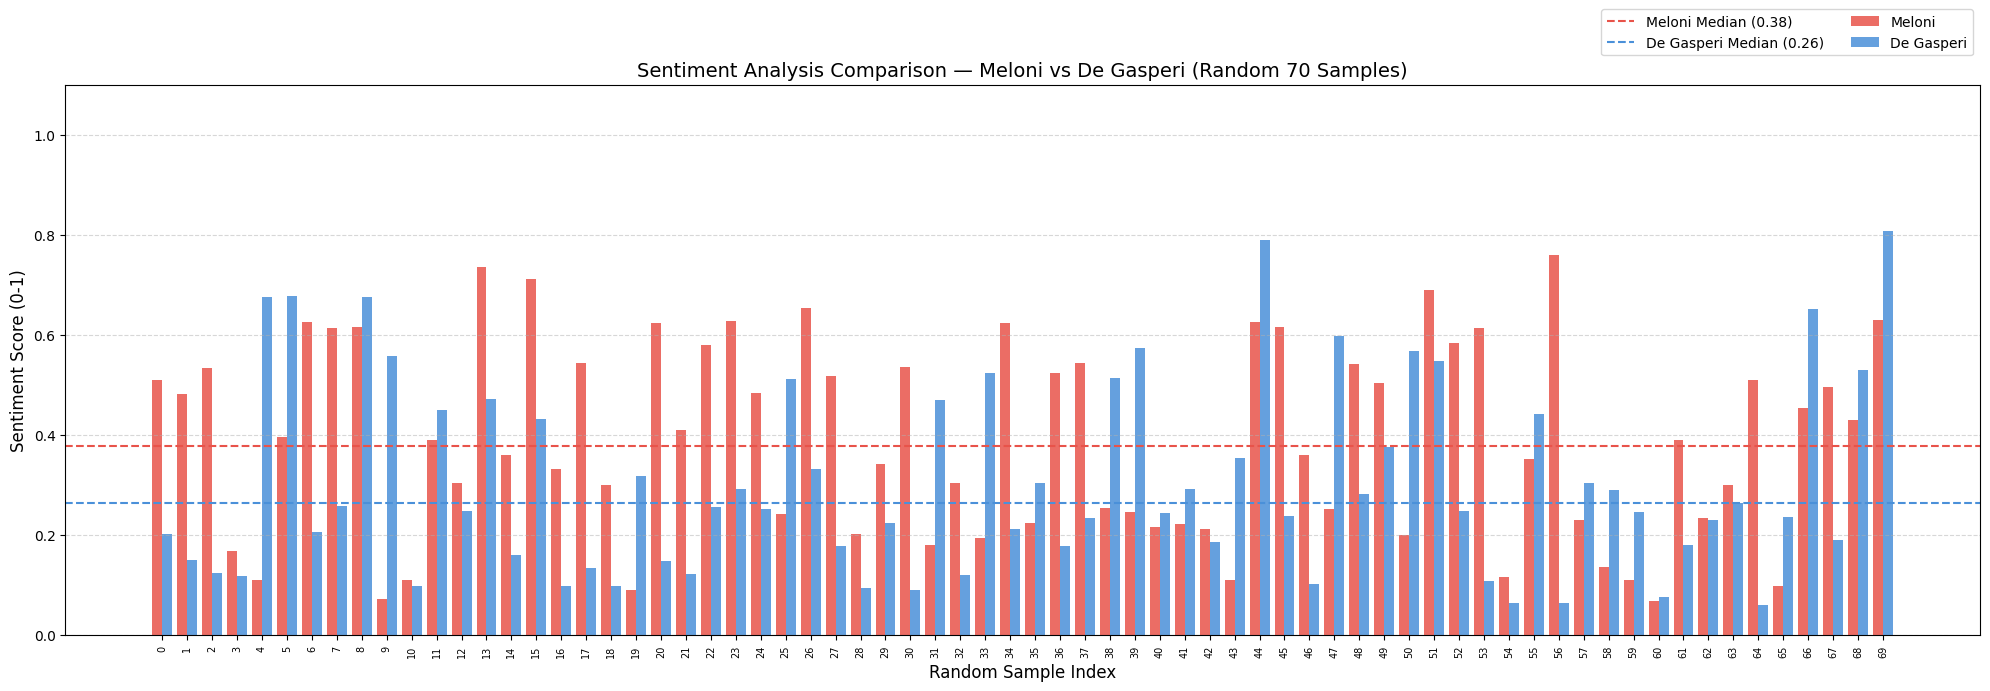

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take 70 random samples from each
# We use .sample(70) and reset the index to align them on the x-axis
meloni_plot = meloni_df["sentiment_aggregated"].sample(70, random_state=42).reset_index(drop=True)
degasperi_plot = degasperi_df["sentiment_aggregated"].sample(70, random_state=42).reset_index(drop=True)

# 2. Calculate medians for the horizontal lines
meloni_med = meloni_df["sentiment_aggregated"].median()
degasperi_med = degasperi_df["sentiment_aggregated"].median()

x = np.arange(70)
width = 0.4

fig, ax = plt.subplots(figsize=(20, 7))

# Plotting the bars side-by-side
ax.bar(x - width/2, meloni_plot, width, label="Meloni", color="#E8534A", alpha=0.85)
ax.bar(x + width/2, degasperi_plot, width, label="De Gasperi", color="#4A90D9", alpha=0.85)

# 3. Add horizontal median lines
ax.axhline(meloni_med, color="#E8534A", linestyle="--", linewidth=1.5, label=f"Meloni Median ({meloni_med:.2f})")
ax.axhline(degasperi_med, color="#4A90D9", linestyle="--", linewidth=1.5, label=f"De Gasperi Median ({degasperi_med:.2f})")

# Formatting
ax.set_xlabel("Random Sample Index", fontsize=12)
ax.set_ylabel("Sentiment Score (0-1)", fontsize=12)
ax.set_title("Sentiment Analysis Comparison — Meloni vs De Gasperi (Random 70 Samples)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90, fontsize=7)
ax.set_ylim(0, 1.1) # Sentiment is bounded 0-1
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.15), ncol=2) # Move legend slightly up
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("sentiment_comparison_70.png", dpi=150)
plt.show()

In [5]:
import pandas as pd
meloni_df = pd.read_csv(f"{BASE_DIR}/datasets/meloni/meloni_processed.csv", index_col=0)
degasperi_df = pd.read_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_processed.csv", index_col=0)

def print_scores(df):
    # Drop rows where sentiment_score is missing
    df["sentiment_score"] = pd.to_numeric(df["sentiment_score"], errors="coerce")

    mean_score  = df["sentiment_score"].mean()
    median_score = df["sentiment_score"].median()

    print(f"Mean sentiment score:   {mean_score:.4f}")
    print(f"Median sentiment score: {median_score:.4f}")

print("=== Meloni ===")
print_scores(meloni_df)
print("== De Gasperi ===")
print_scores(degasperi_df)

=== Meloni ===
Mean sentiment score:   0.4636
Median sentiment score: 0.4692
== De Gasperi ===
Mean sentiment score:   0.4068
Median sentiment score: 0.3627
